# Fraud Detection — EDA & Model Diagnosis
**Dataset:** PaySim (sampled) — 88,213 rows, 8,213 fraud cases (9.31%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

repo_root = Path('..').resolve()
df = pd.read_csv(repo_root / 'data' / 'raw' / 'Datasets.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nDtypes:')
print(df.dtypes)
df.head()

Shape: (88213, 10)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

Dtypes:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,164,CASH_OUT,332924.8600,C1201938726,0.0000,0.0000,C253010635,478954.7600,811879.6200,0
1,65,CASH_OUT,881811.1100,C157136573,881811.1100,0.0000,C882992570,141736.7500,1023547.8500,1
2,228,CASH_OUT,18908.8300,C1714156394,0.0000,0.0000,C972800978,43203.1000,62111.9300,0
3,176,TRANSFER,665489.3300,C399364024,665489.3300,0.0000,C201700405,0.0000,0.0000,1
4,154,CASH_OUT,75023.5700,C1229347323,0.0000,0.0000,C1211492696,83054.5400,158078.1100,0


## 1. Basic Dataset Info

In [2]:
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')
print()
print('=== BASIC STATS ===')
df.describe()

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0

=== BASIC STATS ===


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,88213.0000,88213.0000,88213.0000,88213.0000,88213.0000,88213.0000,88213.0000
mean,254.0540,364773.3159,501164.2171,361140.2419,1352252.6397,1639589.5992,0.0931
std,155.3678,1057216.1464,2171109.9973,1967045.5351,4033953.9875,4346896.4129,0.2906
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,155.0000,44821.0200,0.0000,0.0000,0.0000,85159.6400,0.0000
50%,251.0000,143950.7100,10676.0000,0.0000,306574.1800,518244.3600,0.0000
75%,350.0000,293328.5700,90643.0000,0.0000,1274707.1100,1642155.7700,0.0000
max,743.0000,37448116.0900,59585040.3700,49585040.3700,327998074.2200,328431698.2300,1.0000


## 2. Class Distribution (Fraud vs Legitimate)

=== CLASS DISTRIBUTION ===
Legitimate: 80,000  (90.69%)
Fraud:      8,213   (9.31%)
Imbalance ratio: 9.7:1


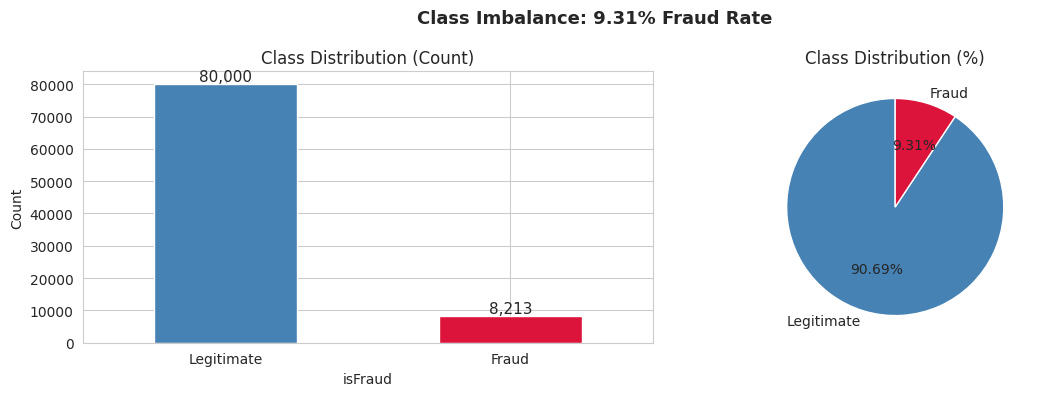

In [3]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print('=== CLASS DISTRIBUTION ===')
print(f'Legitimate: {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)')
print(f'Fraud:      {fraud_counts[1]:,}   ({fraud_pct[1]:.2f}%)')
print(f'Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fraud_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)
fraud_pct.plot(kind='pie', ax=axes[1], autopct='%1.2f%%',
               colors=['steelblue', 'crimson'],
               labels=['Legitimate', 'Fraud'], startangle=90)
axes[1].set_title('Class Distribution (%)')
axes[1].set_ylabel('')
plt.suptitle('Class Imbalance: 9.31% Fraud Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Transaction Type vs Fraud Rate

=== FRAUD RATE BY TRANSACTION TYPE ===
          fraud_count  total  fraud_rate  fraud_rate_pct
type                                                    
TRANSFER         4097  15507      0.2642         26.4203
CASH_OUT         4116  52706      0.0781          7.8094
CASH_IN             0   7798      0.0000          0.0000
DEBIT               0    234      0.0000          0.0000
PAYMENT             0  11968      0.0000          0.0000


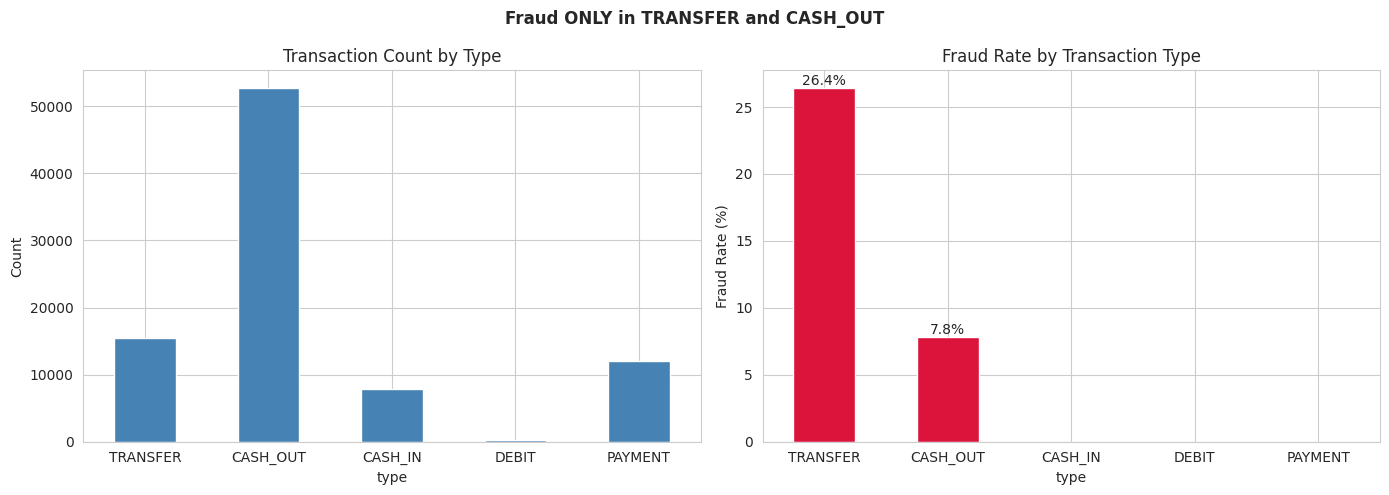

Verdict: TRANSFER has 26.4% fraud rate — strongest type signal!


In [4]:
type_stats = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
type_stats.columns = ['fraud_count', 'total', 'fraud_rate']
type_stats['fraud_rate_pct'] = type_stats['fraud_rate'] * 100
type_stats = type_stats.sort_values('fraud_rate_pct', ascending=False)

print('=== FRAUD RATE BY TRANSACTION TYPE ===')
print(type_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_stats['total'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Count by Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
type_stats['fraud_rate_pct'].plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Fraud Rate by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'{p.get_height():.1f}%',
                         (p.get_x()+p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=10)
plt.suptitle('Fraud ONLY in TRANSFER and CASH_OUT', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Verdict: TRANSFER has 26.4% fraud rate — strongest type signal!')

## 4. Amount Distribution: Fraud vs Legitimate

=== AMOUNT STATISTICS ===
Fraud  mean:    1,467,967.30  median:      441,423.44
Legit  mean:      251,516.66  median:      134,085.50
Fraud is 5.8x larger on average


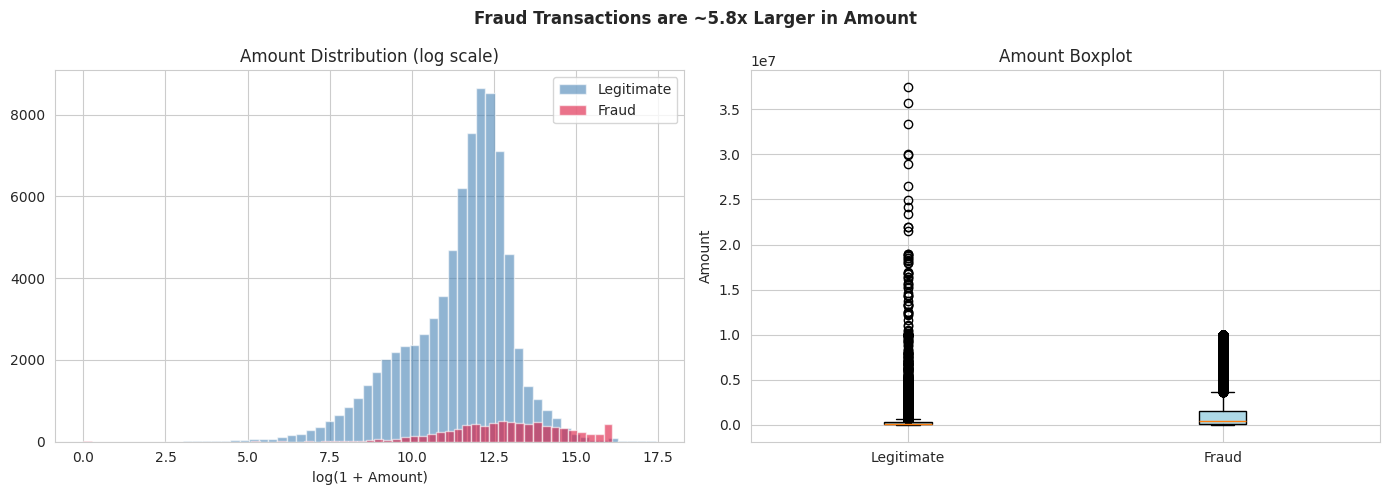

In [5]:
fraud_amounts = df[df['isFraud'] == 1]['amount']
legit_amounts = df[df['isFraud'] == 0]['amount']

print('=== AMOUNT STATISTICS ===')
print(f'Fraud  mean: {fraud_amounts.mean():>15,.2f}  median: {fraud_amounts.median():>15,.2f}')
print(f'Legit  mean: {legit_amounts.mean():>15,.2f}  median: {legit_amounts.median():>15,.2f}')
print(f'Fraud is {fraud_amounts.mean()/legit_amounts.mean():.1f}x larger on average')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.log1p(legit_amounts), bins=60, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].hist(np.log1p(fraud_amounts), bins=60, alpha=0.6, color='crimson',   label='Fraud')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()
axes[1].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'],
                patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Amount Boxplot')
axes[1].set_ylabel('Amount')
plt.suptitle('Fraud Transactions are ~5.8x Larger in Amount', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Balance Patterns — Key Fraud Signals

=== MEAN VALUES: FRAUD vs LEGITIMATE ===
Feature                    Legitimate          Fraud    Ratio
--------------------------------------------------------------
amount                     251,516.66   1,467,967.30    5.84x
oldbalanceOrg              383,255.99   1,649,667.61    4.30x
newbalanceOrig             378,464.29     192,392.63    0.51x
oldbalanceDest           1,435,204.25     544,249.62    0.38x
newbalanceDest           1,676,535.98   1,279,707.62    0.76x

Transactions where sender ends at zero: 68,142
  Of those that are fraud: 8,053 (11.8%)


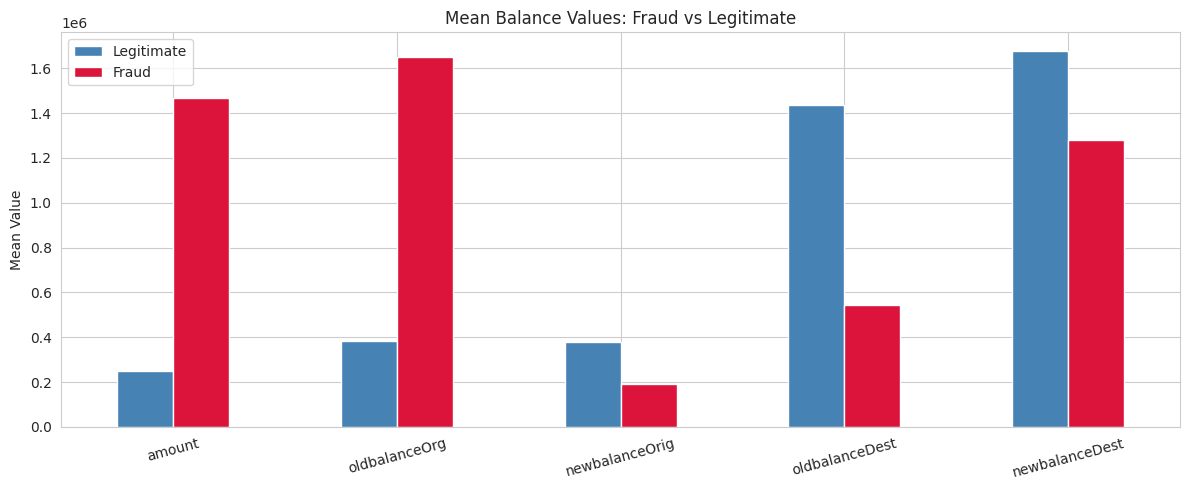

Key insight: Fraud sender oldbalance is HIGH but newbalance drops sharply.


In [6]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

print('=== MEAN VALUES: FRAUD vs LEGITIMATE ===')
print(f'{"Feature":<22} {"Legitimate":>14} {"Fraud":>14} {"Ratio":>8}')
print('-' * 62)
for col in cols:
    legit = df[df['isFraud'] == 0][col].mean()
    fraud = df[df['isFraud'] == 1][col].mean()
    ratio = fraud / legit if legit > 0 else 0
    print(f'{col:<22} {legit:>14,.2f} {fraud:>14,.2f} {ratio:>7.2f}x')

print()
zero_orig = df[df['newbalanceOrig'] == 0]
print(f'Transactions where sender ends at zero: {len(zero_orig):,}')
print(f'  Of those that are fraud: {zero_orig["isFraud"].sum():,} ({zero_orig["isFraud"].mean()*100:.1f}%)')

means = pd.DataFrame({
    'Legitimate': df[df['isFraud']==0][cols].mean(),
    'Fraud':      df[df['isFraud']==1][cols].mean()
})
means.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'crimson'])
plt.title('Mean Balance Values: Fraud vs Legitimate')
plt.ylabel('Mean Value')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()
print('Key insight: Fraud sender oldbalance is HIGH but newbalance drops sharply.')

## 6. Feature Correlations with isFraud

=== CORRELATION WITH isFraud ===
  amount              : +0.3343  █████████████  << STRONG
  step                : +0.2358  █████████  << STRONG
  oldbalanceOrg       : +0.1695  ██████
  newbalanceDest      : -0.0265  █
  newbalanceOrig      : -0.0275  █
  oldbalanceDest      : -0.0642  ██


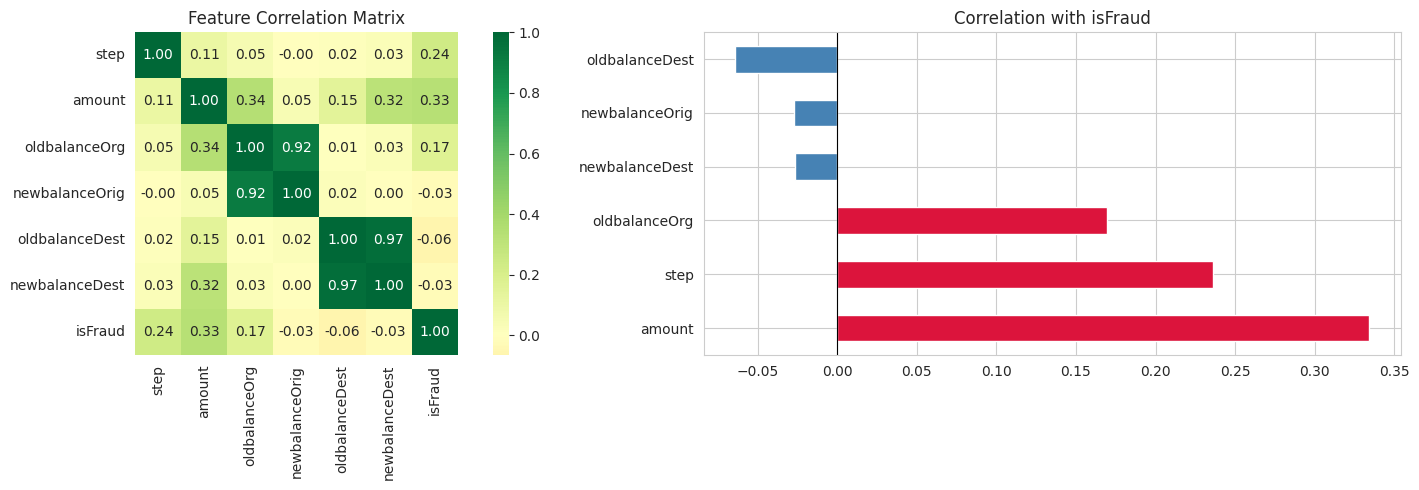

In [7]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[numeric_cols].corr()
fraud_corr = corr['isFraud'].drop('isFraud').sort_values(ascending=False)

print('=== CORRELATION WITH isFraud ===')
for feat, val in fraud_corr.items():
    bar = chr(9608) * int(abs(val) * 40)
    flag = '  << STRONG' if abs(val) > 0.2 else ''
    print(f'  {feat:<20}: {val:+.4f}  {bar}{flag}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')
fraud_corr.plot(kind='barh', ax=axes[1],
                color=['crimson' if v > 0 else 'steelblue' for v in fraud_corr])
axes[1].set_title('Correlation with isFraud')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Engineered Features Preview

In [8]:
df2 = df.copy()
df2['sender_balance_change']   = df2['newbalanceOrig'] - df2['oldbalanceOrg']
df2['receiver_balance_change'] = df2['newbalanceDest'] - df2['oldbalanceDest']
df2['amount_ratio_sender']     = df2['amount'] / (df2['oldbalanceOrg'] + 1)
df2['sender_depletes_account'] = ((df2['newbalanceOrig'] == 0) & (df2['oldbalanceOrg'] > 0)).astype(int)
df2['is_transfer_or_cashout']  = df2['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

eng_cols = ['sender_balance_change', 'receiver_balance_change',
            'amount_ratio_sender', 'sender_depletes_account', 'is_transfer_or_cashout']

print('=== ENGINEERED FEATURE CORRELATIONS WITH isFraud ===')
for col in eng_cols:
    c = df2[col].corr(df2['isFraud'])
    bar = chr(9608) * int(abs(c) * 40)
    print(f'  {col:<30}: {c:+.4f}  {bar}')

print()
dep = df2[df2['sender_depletes_account'] == 1]
print(f'sender_depletes_account=1: {len(dep):,} rows, fraud rate: {dep["isFraud"].mean()*100:.1f}%')
tc = df2[df2['is_transfer_or_cashout'] == 1]
print(f'is_transfer_or_cashout=1:  {len(tc):,} rows, fraud rate: {tc["isFraud"].mean()*100:.1f}%')

=== ENGINEERED FEATURE CORRELATIONS WITH isFraud ===
  sender_balance_change         : -0.4975  ███████████████████
  receiver_balance_change       : +0.1364  █████
  amount_ratio_sender           : -0.0589  ██
  sender_depletes_account       : +0.3738  ██████████████
  is_transfer_or_cashout        : +0.1735  ██████

sender_depletes_account=1: 35,574 rows, fraud rate: 22.5%
is_transfer_or_cashout=1:  68,213 rows, fraud rate: 12.0%


## 8. Summary & Recommendations

In [9]:
print('=' * 65)
print('EDA SUMMARY')
print('=' * 65)
print()
print('DATASET')
print('  Rows:        88,213')
print('  Fraud cases: 8,213  (9.31%)')
print('  Ratio:       9.75:1  — manageable imbalance')
print()
print('KEY FINDINGS')
print('  1. Fraud ONLY in TRANSFER (26.4%) and CASH_OUT (7.8%)')
print('  2. Fraud transactions are ~5.8x larger in amount')
print('  3. Fraud senders drain their account (oldbal high, newbal ~0)')
print('  4. No leakage features — clean dataset')
print('  5. amount and step have strongest raw correlations')
print()
print('FEATURE ENGINEERING PLAN')
print('  Keep:   step, amount, oldbalanceOrg, newbalanceOrig,')
print('          oldbalanceDest, newbalanceDest + type (one-hot)')
print('  Drop:   nameOrig, nameDest (too many unique values)')
print('  Create: sender_balance_change, receiver_balance_change')
print('          amount_ratio_sender, sender_depletes_account')
print('          receiver_had_zero_balance, is_transfer_or_cashout')
print()
print('MODEL PLAN')
print('  Algorithm:  XGBoost')
print('  Imbalance:  scale_pos_weight = 80000/8213 ~ 9.7')
print('  Validation: StratifiedKFold cv=5')
print('  Target:     Recall >= 85%, Precision >= 50%')
print('=' * 65)

EDA SUMMARY

DATASET
  Rows:        88,213
  Fraud cases: 8,213  (9.31%)
  Ratio:       9.75:1  — manageable imbalance

KEY FINDINGS
  1. Fraud ONLY in TRANSFER (26.4%) and CASH_OUT (7.8%)
  2. Fraud transactions are ~5.8x larger in amount
  3. Fraud senders drain their account (oldbal high, newbal ~0)
  4. No leakage features — clean dataset
  5. amount and step have strongest raw correlations

FEATURE ENGINEERING PLAN
  Keep:   step, amount, oldbalanceOrg, newbalanceOrig,
          oldbalanceDest, newbalanceDest + type (one-hot)
  Drop:   nameOrig, nameDest (too many unique values)
  Create: sender_balance_change, receiver_balance_change
          amount_ratio_sender, sender_depletes_account
          receiver_had_zero_balance, is_transfer_or_cashout

MODEL PLAN
  Algorithm:  XGBoost
  Imbalance:  scale_pos_weight = 80000/8213 ~ 9.7
  Validation: StratifiedKFold cv=5
  Target:     Recall >= 85%, Precision >= 50%
